![alt text](68747470733a2f2f692e696d6775722e636f6d2f497a766d62574e2e706e67-1.png)

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma


embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 10,
        'fetch_k': 50,
        'lamda_mult': 0.6
    }
)

In [4]:
from langchain_anthropic import ChatAnthropic
from langsmith import Client


client = Client()

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [5]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: List
    answer: str

In [6]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import Literal



def retrieve(state: AgentState):
    query  = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

relevance_check_prompt = client.pull_prompt('langchain-ai/rag-document-relevance')

def doc_relevance_check_grader(state: AgentState) -> Literal['relevant', 'irrelevant']:
    context = state['context']
    query = state['query']
    doc_relevance_chain = relevance_check_prompt | llm
    response = doc_relevance_chain.invoke({'documents': context, 'question': query})

    if response['Score'] == 1:
        return 'relevant'
    
    return 'irrelevant'



rewrite_prompt = PromptTemplate.from_template("""
당신은 한국 세법 전문가입니다.
사용자의 질문을 소득세법 관련 웹 검색에 최적화된 형태로 다시 작성하세요.

규칙:
1. 일상 용어를 법률 용어로 변환 (예: 월급 → 근로소득)
2. 모호한 표현을 구체화
3. 검색에 필요한 핵심 키워드 포함

예시:
    소득 관련
    '월급, 급여 -> 근로소득',
    '집 팔 때 세금, 부동산 양도 -> 양도소득세',
    '이자, 배당 -> 금융소득',
    '프리랜서 수입, 외주 -> 사업소득',
    '강연료, 원고료 -> 기타소득',
    
    공제 관련
    '부양가족 공제 -> 인적공제',
    '카드 공제 -> 신용카드 소득공제',
    '의료비 공제 -> 의료비 세액공제',
    
    일반 표현
    '세금 돌려받기 -> 환급',
    '세금 신고 -> 확정신고',
    '직장인 연말 세금 -> 연말정산'

원본 질문: {query}
Retrieve 최적화된 질문:
""")

def rewrite(state: AgentState) -> AgentState:
    """
    사용자의 질문을 법률 용어에 적합하게 변경

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 변경된 질문을 포함하는 state를 반환
    """
    
    query = state['query']  # state에서 사용자의 질문 추출
    
    # rewrite 체인을 구성 프롬프트, LLM, 출력 파서 연결
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    # query 변경
    response = rewrite_chain.invoke({'query': query})
    
    return {'query': response}  # 변경된 질문을 포함하는 state 반환



generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm | StrOutputParser()
    response = rag_chain.invoke({'context': context, 'question': query})
    return {'answer': response}

In [7]:
from langchain_community.tools import TavilySearchResults

tavily_search_tool = TavilySearchResults(
    max_results=10,
    search_depth='advanced',
    include_answer=True,
    include_raw_content=True,
    include_images=False
    # include_domains=
    # exclude_domains=
    # name=
    # description=
    # args_schema=
)

def web_search(state: AgentState):
    query = state['query']
    results = tavily_search_tool.invoke(query)
    
    return {'context': results}

In [8]:
# result = tool.invoke({'query': '오늘 서울의 날씨를 요약해줘'})

## Build 시작

In [15]:
from langgraph.graph import StateGraph, START, END


graph_builder = StateGraph(AgentState)


graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
# graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('tavily_search_tool', tavily_search_tool)


graph_builder.add_edge(START, 'retrieve')

graph_builder.add_conditional_edges(
    'retrieve',
    doc_relevance_check_grader,
    {
        'relevant': 'generate',
        'irrelevant': 'tavily_search_tool'
    }
)

graph_builder.add_edge('generate', END)

graph_builder.add_edge('tavily_search_tool', 'generate')


graph = graph_builder.compile()

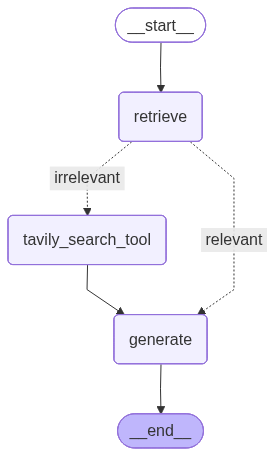

In [16]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
query='원천징수 대상 사업소득에 대해서 알려줘'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [18]:
response['answer']

'원천징수 대상 사업소득은 대통령령으로 정하는 사업소득을 의미합니다. 원천징수의무자가 이러한 사업소득을 지급할 때에는 지급금액에 원천징수세율을 적용하여 계산한 소득세를 원천징수하고, 원천징수영수증을 사업소득자에게 발급해야 합니다. 구체적인 사업의 범위나 세부 기준은 대통령령에서 별도로 정하고 있습니다.'

In [14]:
query='법인세와 소득세의 차이점에 대해 알려줘'
initial_state = {'query': query}
response = graph.invoke(initial_state)

response['answer']

'법인세와 소득세의 주요 차이점은 납세의무자입니다. 소득세는 개인(거주자와 비거주자)의 소득에 대해 부과되는 세금으로, 소득세법 제1조에 따라 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력에 따라 과세됩니다. 반면 법인세는 법인의 소득에 대해 부과되는 세금으로, 문서에서 언급된 내국법인과 외국법인이 납세의무자가 됩니다. 소득세는 개인의 근로소득, 사업소득, 배당소득 등에 대해 누진세율(6%~45%)이 적용되는 반면, 법인세는 법인의 사업소득에 대해 별도의 세율체계가 적용됩니다.'

In [ ]:
## 하고 싶은 것 ##

# retrieved 되고 generated 된 답변에
# LLM이 한차례 더 질문을 하고 필요한 정보를 검색 또는 retrieve로 보충하는 추가 chain

# retrieved 된 문서를 평가하고 추가적인 정보가 필요한지 판단한 뒤 검색하고,
# 검색한 docs와 retrieved 된 docs를 합쳐 컨텍스트 조절을 하는 chain

# Grader들의 정확성을 향상시키기 위한 방법(Golden Dataset)
# 지들이 '알고 있다고 생각'할 뿐인 경우가 너무 많음